In [12]:
import os
import warnings
from IPython.display import display, Markdown

import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm

# Model selection
from sklearn.model_selection import train_test_split, GridSearchCV

# Preprocessing
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.compose import ColumnTransformer

# Feature selection
from sklearn.feature_selection import RFE

# Dimensionality reduction & manifold
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE

# Clustering and mixtures
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture

# Classification / regression models
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor,
    GradientBoostingClassifier,
    GradientBoostingRegressor,
    AdaBoostClassifier,
    AdaBoostRegressor,
)

# Metrics
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    accuracy_score,
    mean_squared_error,
    r2_score,
    silhouette_score,
    silhouette_samples,
    davies_bouldin_score,
)

# Pipeline
from sklearn.pipeline import Pipeline

# Ignore warnings for cleaner output
warnings.filterwarnings('ignore')


In [13]:
# Parámetros
INPUT = "../clean_data/mushrooms_limpio.parquet"
OUTPUT_PARQUET = "../clean_data/mushrooms_limpio_imputed.parquet"
OUTPUT_CSV = "../clean_data/mushrooms_limpio_imputed.csv"
N_NEIGHBORS = 5

# Resumen del análisis
- **Forma:** (8124, 21)
- **Todas las columnas son categóricas** (tipo `str`).
- **Nulos:** 0 en todas las columnas.
- **Balance de clases:** `e` 51.8%, `p` 48.2% (casi balanceado).
- **Variabilidad:** varias columnas con baja cardinalidad (2–6 valores); algunas con más (hasta 12).

Recomendaciones rápidas:
- Para clustering con algoritmos basados en distancia (KMeans, KNN): convertir categóricas con `OneHotEncoder` (sparse), luego reducir dimensión (TruncatedSVD o UMAP) y aplicar `StandardScaler`.
- Si quieres evitar expansión dimensional: usar codificaciones por frecuencia / target encoding / hashing, o usar `KModes` / `k-prototypes` para datos categóricos.
- No escalar variables para métodos basados en árboles o `KModes`.
- Imputación: `SimpleImputer(strategy='most_frequent')` si aparecen nulos en otras fuentes.

In [14]:
# 1) Cargar datos
df = pd.read_parquet(INPUT)

# 2) Reemplazar '?' por NaN en la columna 'stalk root' (y opcionalmente en todo el DF si hay más '?')
df = df.replace('?', np.nan)

# 3) Identificar columnas categóricas
cat_cols = df.select_dtypes(include=['object', 'string', 'category']).columns.tolist()

# 4) Guardar mapeos de categorías y convertir categóricas a códigos (preservando NaN como np.nan)
mappings = {}
df_num = df.copy()
for col in cat_cols:
    df_num[col] = df_num[col].astype('category')
    mappings[col] = df_num[col].cat.categories.tolist()  # lista de categorías en orden
    codes = df_num[col].cat.codes.replace(-1, np.nan).astype('float')  # -1 -> NaN
    df_num[col] = codes

# 5) Aplicar KNNImputer sobre la matriz numérica
imputer = KNNImputer(n_neighbors=N_NEIGHBORS, weights='uniform', metric='nan_euclidean')
imputed_array = imputer.fit_transform(df_num)
df_imputed = pd.DataFrame(imputed_array, columns=df_num.columns, index=df.index)

# 6) Decodificar las columnas categóricas: redondear los códigos y mapear a categorías
for col in cat_cols:
    cats = mappings[col]
    # redondear y convertir a int; clip para evitar índices fuera de rango
    codes = df_imputed[col].round().astype('Int64')  # permite valores NA
    # Mapear códigos NA a NA; para valores numéricos, asegurarnos que estén en rango
    def code_to_cat(val):
        if pd.isna(val):
            return np.nan
        i = int(val)
        i = max(0, min(i, len(cats) - 1))
        return cats[i]
    df_imputed[col] = codes.apply(code_to_cat).astype('category')

# 8) Guardar resultados
df_imputed.to_parquet(OUTPUT_PARQUET, index=False)
df_imputed.to_csv(OUTPUT_CSV, index=False)

print("Imputación completada. Archivos guardados:", OUTPUT_PARQUET, OUTPUT_CSV)

Imputación completada. Archivos guardados: ../clean_data/mushrooms_limpio_imputed.parquet ../clean_data/mushrooms_limpio_imputed.csv


In [15]:
cat_cols = df.select_dtypes(include=['object','string','category']).columns.tolist()

preproc = ColumnTransformer([
        ('imp_ohe', Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=True))
    ]), cat_cols),
], remainder='drop', sparse_threshold=0)

# Ajusta n_components según dimensionalidad (aquí 30 como ejemplo)
n_components = min(30, max(2, len(cat_cols)))
pipe = Pipeline([
    ('preproc', preproc),
    ('svd', TruncatedSVD(n_components=n_components, random_state=0)),
    ('scaler', StandardScaler()),
    ('km', KMeans(n_clusters=3, random_state=0))
])

pipe.fit(df)
labels = pipe.named_steps['km'].labels_
print('clusters assigned:', len(set(labels)))

# Guarda etiquetas
df['cluster'] = labels
df.to_csv('../clean_data/mushrooms_with_clusters.csv', index=False)
print('Wrote ../clean_data/mushrooms_with_clusters.csv')

clusters assigned: 3
Wrote ../clean_data/mushrooms_with_clusters.csv


## Limpieza avanzada
En esta celda aplicamos: eliminación de duplicados, detección/agrupación de niveles raros en categóricas, imputación (numérica: mediana, categórica: moda) y detección básica de outliers numéricos (IQR).
- Para variables categóricas: se agrupan niveles con frecuencia < 1% en `rare` y luego se imputan con la categoría más frecuente.
- Para variables numéricas: se detectan outliers por IQR (se pueden eliminar o winsorizar manualmente).
- Finalmente se guarda `clean_data/mushrooms_cleaned_advanced.csv`.

In [16]:
# 1) Duplicados
dups = df.duplicated().sum()
print('duplicates:', dups)
df = df.drop_duplicates()
print('After drop duplicates shape:', df.shape)

# 2) Identificar numéricas / categóricas
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object','string','category']).columns.tolist()
print('num_cols:', num_cols)
print('cat_cols len:', len(cat_cols))

# Convertir categóricas 'category' a object para poder añadir niveles nuevos
for c in cat_cols:
    # evite Pandas4Warning usando isinstance sobre el dtype CategoricalDtype
    if isinstance(df[c].dtype, pd.CategoricalDtype):
        df[c] = df[c].astype('object')

# 3) Outliers numéricos (IQR)
outlier_summary = {}
for c in num_cols:
    Q1 = df[c].quantile(0.25)
    Q3 = df[c].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    n_out = ((df[c] < lower) | (df[c] > upper)).sum()
    outlier_summary[c] = int(n_out)
print('numeric outliers per col:', outlier_summary)

# 4) Categóricas: agrupar niveles raros (<1%) como 'rare'
rare_thresh = 0.01
cat_rare_counts = {}
for c in cat_cols:
    freqs = df[c].value_counts(normalize=True)
    rare_levels = freqs[freqs < rare_thresh].index.tolist()
    cat_rare_counts[c] = len(rare_levels)
    if rare_levels:
        df[c] = df[c].where(~df[c].isin(rare_levels), other='rare')
print('rare levels replaced per cat col (count):')
print(cat_rare_counts)

# 5) Imputación: numérica -> mediana, categórica -> moda
if num_cols:
    num_imp = SimpleImputer(strategy='median')
    df[num_cols] = num_imp.fit_transform(df[num_cols])

cat_imp = SimpleImputer(strategy='most_frequent')
if cat_cols:
    df[cat_cols] = cat_imp.fit_transform(df[cat_cols])

print('Nulls after imputation:')
print(df.isnull().sum().sum())

# 6) Resumen y guardado
print('Final shape:', df.shape)
out_path = '../clean_data/mushrooms_cleaned_advanced.csv'
df.to_csv(out_path, index=False)
print('Wrote', out_path)

duplicates: 0
After drop duplicates shape: (8124, 23)
num_cols: ['cluster']
cat_cols len: 22
numeric outliers per col: {'cluster': 0}
rare levels replaced per cat col (count):
{'class': 0, 'cap-shape': 2, 'cap-surface': 1, 'cap-color': 3, 'bruises': 0, 'odor': 1, 'gill-attachment': 0, 'gill-spacing': 0, 'gill-size': 0, 'gill-color': 2, 'stalk-shape': 0, 'stalk-root': 0, 'stalk-surface-above-ring': 1, 'stalk-surface-below-ring': 0, 'stalk-color-above-ring': 2, 'stalk-color-below-ring': 2, 'veil-color': 1, 'ring-number': 1, 'ring-type': 2, 'spore-print-color': 5, 'population': 0, 'habitat': 0}
Nulls after imputation:
0
Final shape: (8124, 23)
Wrote ../clean_data/mushrooms_cleaned_advanced.csv


## Reducción de dimensionalidad: PCA + t-SNE
Aplicamos dos técnicas complementarias:
1. **PCA (Principal Component Analysis):** Reduce preservando 95% de la varianza. Útil para entrenar modelos rápidamente con menos features.
2. **t-SNE (t-Distributed Stochastic Neighbor Embedding):** Reduce a 2D manteniendo la estructura local de los datos. Perfecto para visualización.

Proceso:
- OneHotEncode las columnas categóricas → 113 features
- StandardScaler para normalizar
- PCA con 95% varianza → ~59 componentes
- t-SNE en 2D (después de reducir PCA a 50 dims para eficiencia) → visualización
- Guardar ambas versiones en CSV para usar en modelos posteriores

In [17]:
# Identificar columnas categóricas y numéricas
cat_cols = df.select_dtypes(include=['object','category']).columns.tolist()
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print('cat_cols:', len(cat_cols), '| num_cols:', len(num_cols))

# 1) OneHotEncode + StandardScaler
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
], remainder='passthrough' if num_cols else 'drop')

X = preprocessor.fit_transform(df[cat_cols + num_cols])
print('After OneHot shape:', X.shape)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2) PCA con 95% de varianza
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)
print(f'After PCA (95% var) shape: {X_pca.shape}')
print(f'Explained variance: {pca.explained_variance_ratio_.sum():.4f}')

# 3) t-SNE (primero reducir a 50 dims para eficiencia)
dims_for_tsne = min(50, X_pca.shape[1])
if X_pca.shape[1] > dims_for_tsne:
    pca_reduce = PCA(n_components=dims_for_tsne)
    X_pca_reduced = pca_reduce.fit_transform(X_pca)
else:
    X_pca_reduced = X_pca

print('Input to t-SNE shape:', X_pca_reduced.shape)
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_pca_reduced)
print('After t-SNE shape:', X_tsne.shape)

# 4) Guardar resultados
df_pca = pd.DataFrame(X_pca, columns=[f'pca_{i}' for i in range(X_pca.shape[1])])
df_tsne = pd.DataFrame(X_tsne, columns=['tsne_1', 'tsne_2'])

# Añadir clase original si existe
if 'class' in df.columns:
    df_pca['class'] = df['class'].values
    df_tsne['class'] = df['class'].values

df_pca.to_csv('../clean_data/mushrooms_pca.csv', index=False)
df_tsne.to_csv('../clean_data/mushrooms_tsne.csv', index=False)

print(f'Saved: mushrooms_pca.csv ({df_pca.shape}), mushrooms_tsne.csv ({df_tsne.shape})')

cat_cols: 22 | num_cols: 1
After OneHot shape: (8124, 107)
After PCA (95% var) shape: (8124, 54)
Explained variance: 0.9537
Input to t-SNE shape: (8124, 50)


After t-SNE shape: (8124, 2)
Saved: mushrooms_pca.csv ((8124, 55)), mushrooms_tsne.csv ((8124, 3))


## Selección de variables y clustering no supervisado

Esta celda identifica columnas categóricas "útiles" descartando columnas constantes, casi constantes (≥95% de la misma categoría) y con alta cardinalidad (>50 niveles).
A continuación realiza codificación (one-hot), reduce la dimensión con `TruncatedSVD` y aplica `KMeans` probando k entre 2 y 5. Se evalúa cada partición con la puntuación de silhouette y se guarda la mejor asignación en `clean_data/mushrooms_with_clusters.csv`.

Puntos a tener en cuenta:
- Si quedan menos de 2 variables útiles, se añaden columnas candidatas con cardinalidad ≤100 (hasta 5).
- Para datasets grandes preferible usar `OneHotEncoder(sparse_output=True)` y aplicar `TruncatedSVD` sobre la matriz dispersa para ahorrar memoria.
- Ajusta umbrales (`top_freq`, `n_unique`) según tus necesidades.


In [18]:
# Selección de variables útiles y clustering no supervisado
# Analizamos columnas categóricas y descartamos constantes/quasi-constantes/alta cardinalidad
cat_cols = df.select_dtypes(include=['object','string','category']).columns.tolist()
if 'class' in cat_cols:
    cat_cols.remove('class')
summary = []
drop_reasons = {}
useful = []
for c in cat_cols:
    n_unique = df[c].nunique(dropna=False)
    top_freq = df[c].value_counts(normalize=True, dropna=False).iloc[0]
    n_missing = int(df[c].isna().sum())
    reason = []
    if n_unique <= 1:
        reason.append('constant')
    if top_freq >= 0.95:
        reason.append('quasi_constant')
    if n_unique > 50:
        reason.append('high_cardinality')
    if reason:
        drop_reasons[c] = ','.join(reason)
    else:
        useful.append(c)
    summary.append({'col':c,'n_unique':int(n_unique),'top_freq':float(top_freq),'n_missing':n_missing,'keep': c in useful})
print('Variables analizadas:', len(cat_cols))
print('Conservar (ejemplo 20):', useful[:20])
print('Descartar (ejemplo 20):', list(drop_reasons.items())[:20])
summary_df = pd.DataFrame(summary)
display(summary_df.sort_values(['keep','n_unique'], ascending=[False,False]).head(50))
# Preparar features para clustering usando las útiles (ajusta umbrales si hace falta)
features = useful
# Si no hay suficientes features útiles, incluir columnas con alta cardinalidad controladamente
if len(features) < 2:
    candidates = [c for c in cat_cols if c not in features and df[c].nunique() <= 100][:5]
    features += candidates
    print('Añadidos candidatos por falta de features útiles:', candidates)
# One-hot encode (dense) - para datasets grandes usa sparse_output=True y TruncatedSVD sobre sparse matrix
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_ohe = ohe.fit_transform(df[features])
print('After OHE shape:', X_ohe.shape)
# Reducir dimensión con TruncatedSVD para acelerar clustering
n_components = min(20, max(2, X_ohe.shape[1] // 10))
svd = TruncatedSVD(n_components=n_components, random_state=0)
X_red = svd.fit_transform(X_ohe)
print('After SVD shape:', X_red.shape)
# Buscar el mejor k con silhouette entre 2 y 5
best = {'score': -1, 'n_clusters': None, 'labels': None}
for k in range(2, 6):
    km = KMeans(n_clusters=k, random_state=0, n_init=10)
    labels = km.fit_predict(X_red)
    try:
        score = silhouette_score(X_red, labels)
    except Exception:
        score = -1
    print(f'k={k} silhouette={score:.4f}')
    if score > best['score']:
        best.update({'score': score, 'n_clusters': k, 'labels': labels})
print('Mejor k:', best['n_clusters'], 'score:', best['score'])
df['cluster_unsupervised'] = best['labels'] if best['labels'] is not None else pd.NA
out_path = '../clean_data/mushrooms_with_clusters.csv'
df.to_csv(out_path, index=False)
print('Guardado', out_path)

Variables analizadas: 21
Conservar (ejemplo 20): ['cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat']
Descartar (ejemplo 20): [('gill-attachment', 'quasi_constant'), ('veil-color', 'quasi_constant')]


,col,n_unique,top_freq,n_missing,keep
8,gill-color,11,0.212703,0,True
4,odor,9,0.434269,0,True
2,cap-color,8,0.281142,0,True
13,stalk-color-above-ring,8,0.549483,0,True
14,stalk-color-below-ring,8,0.539636,0,True
20,habitat,7,0.387494,0,True
19,population,6,0.497292,0,True
0,cap-shape,5,0.450025,0,True
18,spore-print-color,5,0.293944,0,True
1,cap-surface,4,0.399311,0,True


After OHE shape: (8124, 98)
After SVD shape: (8124, 9)
k=2 silhouette=0.2856
k=3 silhouette=0.3770
k=4 silhouette=0.4134
k=5 silhouette=0.4690
Mejor k: 5 score: 0.46896817614040026
Guardado ../clean_data/mushrooms_with_clusters.csv


## Aplicación de modelos de clustering

En esta sección cargamos los archivos ya generados (PCA/t-SNE) y aplicamos varios algoritmos de clustering: `KMeans`, `GaussianMixture`, `AgglomerativeClustering` y `DBSCAN`.
Se calcula la puntuación de silhouette para comparar particiones y se guardan los CSVs resultantes con las etiquetas de cluster.


In [19]:
# Rutas de entrada (generadas anteriormente)
pca_path = '../clean_data/mushrooms_pca.csv'
tsne_path = '../clean_data/mushrooms_tsne.csv'
clusters_path = '../clean_data/mushrooms_with_clusters.csv'
out_pca = '../clean_data/mushrooms_pca_clustered.csv'

# Cargar PCA si existe, si no avisar
if not os.path.exists(pca_path):
    print('No se encontró', pca_path, '; asegura que ejecutaste la celda de PCA anteriormente.')
else:
    df_pca = pd.read_csv(pca_path)
    feats = [c for c in df_pca.columns if c.startswith('pca_')]
    X = df_pca[feats].values
    X = StandardScaler().fit_transform(X)

    results = {}
    # KMeans para k en 2..5
    for k in range(2,6):
        km = KMeans(n_clusters=k, random_state=0, n_init=10)
        labels = km.fit_predict(X)
        try:
            sil = silhouette_score(X, labels)
        except Exception:
            sil = float('nan')
        db = davies_bouldin_score(X, labels)
        col = f'kmeans_{k}'
        df_pca[col] = labels
        results[col] = {'silhouette': sil, 'db_index': db}
        print(f'KMeans k={k} silhouette={sil:.4f} db={db:.4f}')

    # Gaussian Mixture (GMM) - try components 2..5
    for k in range(2,6):
        gmm = GaussianMixture(n_components=k, random_state=0)
        labels = gmm.fit_predict(X)
        try:
            sil = silhouette_score(X, labels)
        except Exception:
            sil = float('nan')
        db = davies_bouldin_score(X, labels)
        col = f'gmm_{k}'
        df_pca[col] = labels
        results[col] = {'silhouette': sil, 'db_index': db}
        print(f'GMM k={k} silhouette={sil:.4f} db={db:.4f}')

    # Agglomerative (k=3 as example)
    agg = AgglomerativeClustering(n_clusters=3)
    labels = agg.fit_predict(X)
    try:
        sil = silhouette_score(X, labels)
    except Exception:
        sil = float('nan')
    db = davies_bouldin_score(X, labels)
    df_pca['agg_3'] = labels
    results['agg_3'] = {'silhouette': sil, 'db_index': db}
    print(f'Agglomerative k=3 silhouette={sil:.4f} db={db:.4f}')

    # DBSCAN (eps y min_samples pueden necesitar ajuste)
    dbscan = DBSCAN(eps=0.5, min_samples=5)
    labels = dbscan.fit_predict(X)
    # DBSCAN puede asignar -1 a ruido; silhouette no admite un solo cluster
    try:
        valid = labels >= 0
        if len(set(labels[valid])) > 1:
            sil = silhouette_score(X[valid], labels[valid])
        else:
            sil = float('nan')
    except Exception:
        sil = float('nan')
    df_pca['dbscan'] = labels
    print('DBSCAN clusters (unique):', set(labels))
    results['dbscan'] = {'silhouette': sil}

    # Guardar resultados PCA con etiquetas de cluster
    df_pca.to_csv(out_pca, index=False)
    print('Guardado:', out_pca)
    # Mostrar tabla resumen de scores
    scores_df = pd.DataFrame([{ 'method':k, **v} for k,v in results.items()])
    display(scores_df.sort_values('silhouette', ascending=False))

KMeans k=2 silhouette=0.2807 db=1.5183
KMeans k=3 silhouette=0.0163 db=4.2307
KMeans k=4 silhouette=0.0336 db=4.7032
KMeans k=5 silhouette=0.0310 db=3.9730
GMM k=2 silhouette=0.3058 db=1.7020
GMM k=3 silhouette=0.0201 db=5.6271
GMM k=4 silhouette=0.0138 db=5.4470
GMM k=5 silhouette=-0.0028 db=5.1047
Agglomerative k=3 silhouette=0.2855 db=1.5120
DBSCAN clusters (unique): {np.int64(-1)}
Guardado: ../clean_data/mushrooms_pca_clustered.csv


,method,silhouette,db_index
4,gmm_2,0.305786,1.701995
8,agg_3,0.285522,1.512023
0,kmeans_2,0.280693,1.518294
2,kmeans_4,0.033571,4.703168
3,kmeans_5,0.031033,3.973036
5,gmm_3,0.020065,5.627133
1,kmeans_3,0.016264,4.230674
6,gmm_4,0.013834,5.447038
7,gmm_5,-0.002791,5.104736
9,dbscan,NaN,NaN


### Análisis de Silhouette
Añadimos gráficas útiles para evaluar la calidad del clustering: (1) puntuación media de silhouette según `k`, y (2) el silhouette plot detallado para el `k` que maximiza la puntuación media.

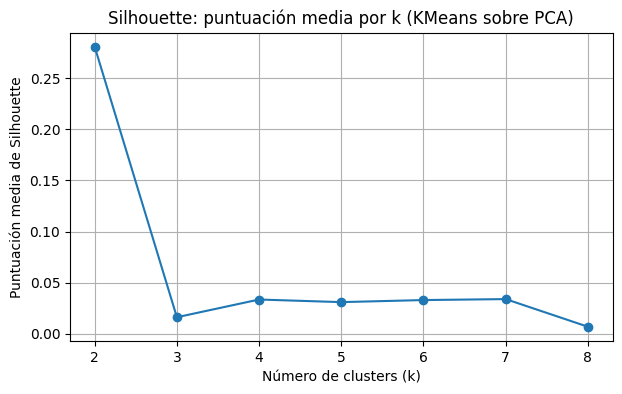

Best k by silhouette: 2


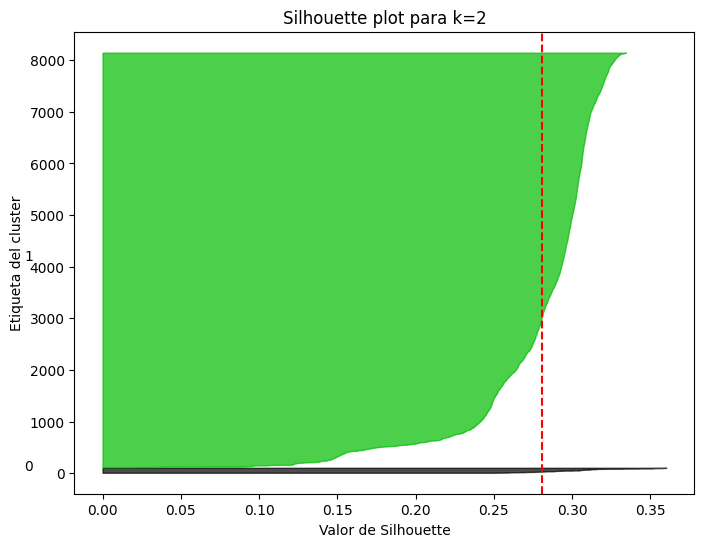

In [20]:
# Título y explicación breve (se muestra como Markdown)
display(Markdown('''### Análisis de Silhouette
Añadimos gráficas útiles para evaluar la calidad del clustering: (1) puntuación media de silhouette según `k`, y (2) el silhouette plot detallado para el `k` que maximiza la puntuación media.'''))

# Asegurarnos de tener df_pca cargado
if 'df_pca' not in globals():
    if os.path.exists(pca_path):
        df_pca = pd.read_csv(pca_path)
    else:
        raise FileNotFoundError(f'No se encontró {pca_path}. Ejecuta la sección de PCA primero.')

feats = [c for c in df_pca.columns if c.startswith('pca_')]
X = df_pca[feats].values
X = StandardScaler().fit_transform(X)

range_n_clusters = range(2, 9)
avg_scores = []
for n_clusters in range_n_clusters:
    km = KMeans(n_clusters=n_clusters, random_state=0, n_init=10)
    labels = km.fit_predict(X)
    try:
        score = silhouette_score(X, labels)
    except Exception:
        score = float('nan')
    avg_scores.append(score)

# Gráfico de puntuación media por k
plt.figure(figsize=(7,4))
plt.plot(list(range_n_clusters), avg_scores, marker='o')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Puntuación media de Silhouette')
plt.title('Silhouette: puntuación media por k (KMeans sobre PCA)')
plt.grid(True)
plt.show()

# Elegir mejor k (excluyendo NaN)
valid_scores = [(k,s) for k,s in zip(range_n_clusters, avg_scores) if not np.isnan(s)]
if valid_scores:
    best_k = max(valid_scores, key=lambda x: x[1])[0]
    print(f'Best k by silhouette: {best_k}')
    # Silhouette plot para best_k
    km = KMeans(n_clusters=best_k, random_state=0, n_init=10)
    cluster_labels = km.fit_predict(X)
    silhouette_vals = silhouette_samples(X, cluster_labels)
    y_lower = 10
    plt.figure(figsize=(8,6))
    for i in range(best_k):
        ith_silhouette_vals = silhouette_vals[cluster_labels == i]
        ith_silhouette_vals.sort()
        size_cluster_i = ith_silhouette_vals.shape[0]
        y_upper = y_lower + size_cluster_i
        color = cm.nipy_spectral(float(i) / best_k)
        plt.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_silhouette_vals, facecolor=color, edgecolor=color, alpha=0.7)
        plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10  # espacio entre clusters
    plt.xlabel('Valor de Silhouette')
    plt.ylabel('Etiqueta del cluster')
    plt.title(f'Silhouette plot para k={best_k}')
    plt.axvline(x=np.mean(silhouette_vals), color='red', linestyle='--')
    plt.show()
else:
    print('No hay puntuaciones válidas de silhouette para el rango elegido.')

### Visualizaciones adicionales: PCA y t-SNE
Se muestran: (1) PCA PC1 vs PC2 coloreado por la clase real y por los clusters KMeans, (2) t-SNE coloreado por la clase (si existe), y (3) un bar chart con el tamaño de cada cluster.

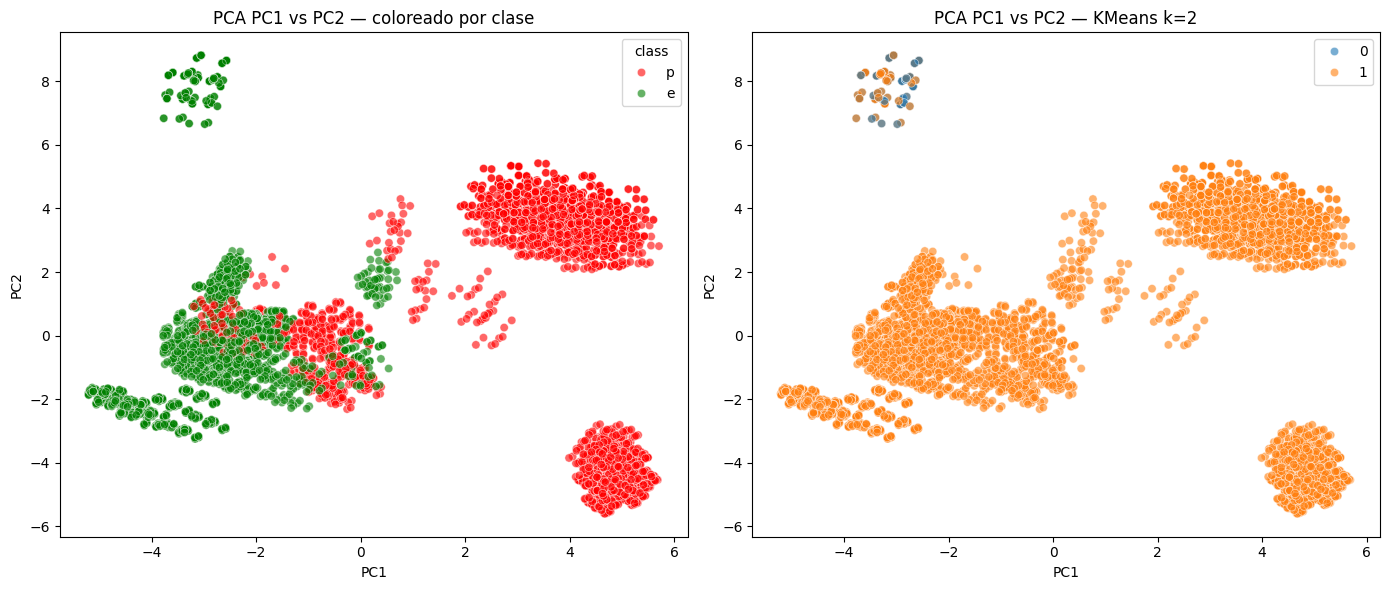

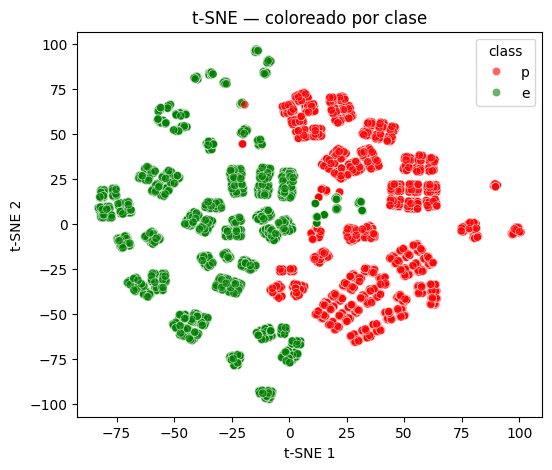

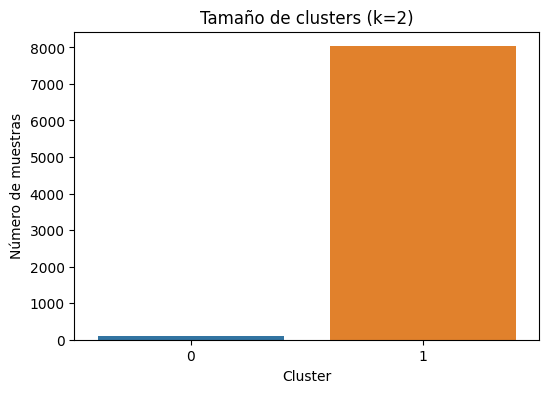

In [21]:
# Cabecera breve
display(Markdown('''### Visualizaciones adicionales: PCA y t-SNE
Se muestran: (1) PCA PC1 vs PC2 coloreado por la clase real y por los clusters KMeans, (2) t-SNE coloreado por la clase (si existe), y (3) un bar chart con el tamaño de cada cluster.'''))

# Cargar df_pca si no está en memoria
if 'df_pca' not in globals():
    if os.path.exists(pca_path):
        df_pca = pd.read_csv(pca_path)
    else:
        raise FileNotFoundError(f'No se encontró {pca_path}. Ejecuta la sección de PCA primero.')

feats = [c for c in df_pca.columns if c.startswith('pca_')]
if not feats:
    raise ValueError('No se encontraron columnas PCA en df_pca.')

X = StandardScaler().fit_transform(df_pca[feats].values)

# Determinar etiquetas de cluster: preferir 'best_k' si existe, sino buscar columnas kmeans_ en df_pca, sino computar kmeans(k=4)
try:
    bk = best_k
except NameError:
    bk = None

cluster_labels = None
if bk is None:
    km_cols = [c for c in df_pca.columns if c.startswith('kmeans_')]
    if km_cols:
        # usar la última columna kmeans encontrada
        km_col = km_cols[-1]
        cluster_labels = df_pca[km_col].values
        bk = int(km_col.split('_')[1])

if cluster_labels is None:
    bk = bk or 4
    km = KMeans(n_clusters=bk, random_state=0, n_init=10)
    cluster_labels = km.fit_predict(X)

# 1) PCA scatter: clase vs cluster (lado a lado)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
if 'class' in df_pca.columns:
    sns.scatterplot(x=df_pca['pca_0'], y=df_pca['pca_1'], hue=df_pca['class'], palette={'e':'green','p':'red'}, alpha=0.6, ax=axes[0])
    axes[0].set_title('PCA PC1 vs PC2 — coloreado por clase')
else:
    axes[0].scatter(df_pca['pca_0'], df_pca['pca_1'], alpha=0.6)
    axes[0].set_title('PCA PC1 vs PC2')

sns.scatterplot(x=df_pca['pca_0'], y=df_pca['pca_1'], hue=cluster_labels, palette='tab10', alpha=0.6, ax=axes[1])
axes[1].set_title(f'PCA PC1 vs PC2 — KMeans k={bk}')
for ax in axes:
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
plt.tight_layout()
plt.show()

# 2) t-SNE scatter (si existe el CSV generado antes)
if os.path.exists(tsne_path):
    df_tsne = pd.read_csv(tsne_path)
    plt.figure(figsize=(6,5))
    if 'class' in df_tsne.columns:
        sns.scatterplot(x='tsne_1', y='tsne_2', hue='class', data=df_tsne, palette={'e':'green','p':'red'}, alpha=0.6)
        plt.title('t-SNE — coloreado por clase')
    else:
        sns.scatterplot(x='tsne_1', y='tsne_2', data=df_tsne, alpha=0.6)
        plt.title('t-SNE')
    plt.xlabel('t-SNE 1')
    plt.ylabel('t-SNE 2')
    plt.show()
else:
    print(f'No se encontró {tsne_path} — omitiendo gráfico t-SNE.')

# 3) Bar chart: tamaño de clusters
unique, counts = np.unique(cluster_labels, return_counts=True)
order = np.argsort(unique)
plt.figure(figsize=(6,4))
sns.barplot(x=unique[order].astype(str), y=counts[order], palette='tab10')
plt.xlabel('Cluster')
plt.ylabel('Número de muestras')
plt.title(f'Tamaño de clusters (k={bk})')
plt.show()

## Entrenamiento: detección de tipo de problema y ensembles

Esta sección detecta automáticamente si el objetivo es regresión o clasificación (buscando columnas típicas como `class`), divide los datos en `train/test` y entrena varios modelos ensemble: `RandomForest`, `GradientBoosting`, `AdaBoost`, `XGBoost` y `LightGBM` (si están instalados).
Se generan métricas relevantes (accuracy, precision, recall, f1, roc_auc cuando aplica) y se guardan los scores en `clean_data/model_scores.csv`. También se guardan los modelos entrenados en `models/` si lo deseas.


In [22]:
# Preferir datasets ya procesados (PCA clusterizados), sino caer al PCA/df original
candidates = ["../clean_data/mushrooms_pca_clustered.csv", "../clean_data/mushrooms_pca.csv", "../clean_data/mushrooms_with_clusters.csv"]
data_path = None
for p in candidates:
    if os.path.exists(p):
        data_path = p
        break
if data_path is None:
    raise FileNotFoundError('No se encontró un dataset procesado. Ejecuta las celdas anteriores para generar PCA/Clusters.')
print('Usando dataset:', data_path)
df_final = pd.read_csv(data_path)
# Detectar columna objetivo: preferimos 'class' si existe, sino 'cluster' o 'target'
target_cols = [c for c in ['class','target','label','cluster','cluster_unsupervised'] if c in df_final.columns]
if not target_cols:
    raise ValueError('No se encontró columna objetivo conocida (class/target/label/cluster).')
target = target_cols[0]
y = df_final[target].copy()
# Decidir tipo: si y es numérico con muchas opciones => regresión; si no => clasificación
is_regression = pd.api.types.is_numeric_dtype(y) and y.nunique() > 20
print('Objetivo:', target, '| Regresión' if is_regression else '| Clasificación')
# Preparar X: elegir columnas numéricas (p.ej. pca_) o todas menos target
if any(col.startswith('pca_') for col in df_final.columns):
    X = df_final[[c for c in df_final.columns if c.startswith('pca_')]]
else:
    X = df_final.drop(columns=[target])
# Si hay columnas no numéricas, hacer one-hot mínimo
X = X.copy()
non_num = X.select_dtypes(include=['object','category','string']).columns.tolist()
if non_num:
    X = pd.get_dummies(X, columns=non_num, drop_first=True)
print('Feature matrix shape:', X.shape)
# Encode target if classification and not numeric
if not is_regression:
    le = LabelEncoder()
    y_enc = le.fit_transform(y.astype(str))
else:
    y_enc = y.values.astype(float)
# Train/test split (estratificar si clasificación)
stratify = y_enc if not is_regression else None
X_train, X_test, y_train, y_test = train_test_split(X, y_enc, test_size=0.2, random_state=0, stratify=stratify)
# Escalar numéricos
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
# Model list según tipo
models = {}
if is_regression:
    models['RF'] = RandomForestRegressor(n_estimators=100, random_state=0)
    models['GBoost'] = GradientBoostingRegressor(random_state=0)
    models['Ada'] = AdaBoostRegressor(random_state=0)
else:
    models['RF'] = RandomForestClassifier(n_estimators=200, random_state=0)
    models['GBoost'] = GradientBoostingClassifier(random_state=0)
    models['Ada'] = AdaBoostClassifier(random_state=0)
# Intentar añadir XGBoost y LightGBM si están instalados
try:
    models['XGB'] = XGBRegressor(random_state=0) if is_regression else XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=0)
except Exception:
    print('xgboost no disponible, se omitirá')
try:
    models['LGBM'] = LGBMRegressor(random_state=0) if is_regression else LGBMClassifier(random_state=0)
except Exception:
    print('lightgbm no disponible, se omitirá')
# Entrenar y evaluar
results = []
os.makedirs('models', exist_ok=True)
for name, model in models.items():
    print('Entrenando', name)
    model.fit(X_train, y_train)
    joblib.dump(model, f'models/{name}.joblib')
    y_pred = model.predict(X_test)
    row = {'model': name}
    if is_regression:
        row.update({'mse': mean_squared_error(y_test, y_pred), 'r2': r2_score(y_test, y_pred)})
    else:
        row.update({'accuracy': accuracy_score(y_test, y_pred), 'precision': precision_score(y_test, y_pred, zero_division=0), 'recall': recall_score(y_test, y_pred, zero_division=0), 'f1': f1_score(y_test, y_pred, zero_division=0)})
        # ROC AUC si hay predict_proba y problema binario
        if hasattr(model, 'predict_proba') and len(set(y_test)) == 2:
            proba = model.predict_proba(X_test)[:,1]
            row['roc_auc'] = roc_auc_score(y_test, proba)
    results.append(row)
    print('Eval', row)
# Guardar scores
res_df = pd.DataFrame(results)
res_df.to_csv('../clean_data/model_scores.csv', index=False)
print('Scores guardados en ../clean_data/model_scores.csv')
display(res_df)
# Guardar scaler también
joblib.dump(scaler, 'models/scaler.joblib')
print('Modelos y scaler guardados en /models')

Usando dataset: ../clean_data/mushrooms_pca_clustered.csv
Objetivo: class | Clasificación
Feature matrix shape: (8124, 54)
Entrenando RF
Eval {'model': 'RF', 'accuracy': 0.9987692307692307, 'precision': 1.0, 'recall': 0.9974457215836526, 'f1': 0.9987212276214834, 'roc_auc': 1.0}
Entrenando GBoost
Eval {'model': 'GBoost', 'accuracy': 0.9969230769230769, 'precision': 1.0, 'recall': 0.9936143039591315, 'f1': 0.9967969250480462, 'roc_auc': 0.9999757313214599}
Entrenando Ada
Eval {'model': 'Ada', 'accuracy': 0.9975384615384615, 'precision': 1.0, 'recall': 0.9948914431673053, 'f1': 0.9974391805377721, 'roc_auc': 0.9999833152835037}
Entrenando XGB
Eval {'model': 'XGB', 'accuracy': 0.9981538461538462, 'precision': 1.0, 'recall': 0.9961685823754789, 'f1': 0.9980806142034548, 'roc_auc': 0.9999969664151824}
Entrenando LGBM
[LightGBM] [Info] Number of positive: 3133, number of negative: 3366
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001283 seconds.
You

,model,accuracy,precision,recall,f1,roc_auc
0,RF,0.998769,1.0,0.997446,0.998721,1.000000
1,GBoost,0.996923,1.0,0.993614,0.996797,0.999976
2,Ada,0.997538,1.0,0.994891,0.997439,0.999983
3,XGB,0.998154,1.0,0.996169,0.998081,0.999997
4,LGBM,0.998769,1.0,0.997446,0.998721,0.999944


Modelos y scaler guardados en /models
